# Prediksi Probabilitas Kebotakan — Data Cleaning, EDA & Machine Learning

Notebook ini menggunakan dataset `botak_kotor.csv` (sintetis untuk latihan) dan alur data cleaning dari `Data_Preprocessing.ipynb` (materi **Fullstack Bangalore AI Engineer Bootcamp**) sebagai basis. Bagian eksplorasi data (EDA) dan pemodelan machine learning selanjutnya dikerjakan secara mandiri.

**Alur:** Load → Eksplorasi → Cleaning (missing value, duplikat, teks, tipe data) → EDA → Outlier (IQR) → Encoding → Split → Modeling (Cross-Validation) → Simpan Model → Inferensi Data Baru

---
### Ringkasan pendekatan
1. **Missing value ditangani di semua 14 kolom**, termasuk kolom `stress`.
2. **Baris dengan target (`botak_prob`) kosong di-drop**, bukan diisi median — mengisi label dengan median akan mencemari data training.
3. **Kolom biner** (`is_menikah`, `is_keturunan`, `is_merokok`) diisi dengan **modus**, bukan median/mean — lebih tepat untuk data 0/1.
4. **Scaling (MinMaxScaler) dibungkus dalam `Pipeline`** bersama tiap model, di-*fit* ulang di setiap fold cross-validation — mengisolasi data test dari proses fitting scaler.
5. **`random_state=42`** dipakai di split & cross-validation — hasil evaluasi jadi reproducible.
6. **Kolom `stress`** dimasukkan sebagai fitur.
7. **Mapping encoding kategori didefinisikan sekali** dalam satu dict lalu dipakai ulang saat training *dan* saat inferensi data baru — menghindari duplikasi kode.
8. **Model terbaik dipilih otomatis** berdasarkan rata-rata RMSE 5-fold cross-validation, bukan disebut manual di teks.
9. **Pipeline (scaler + model), mapping encoding, dan daftar fitur disimpan bersama** dalam satu file — data baru bisa langsung diproses & diprediksi tanpa langkah manual tambahan.
10. Kolom `gaji` dan `provinsi` **tidak dipakai sebagai fitur** karena secara logis tidak relevan sebagai prediktor kebotakan.


## 1) Setup & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from statistics import mode
import pickle

%matplotlib inline

# --- Font Inter (identitas visual "AI Notes & Engineering") ---
import io, zipfile, urllib.request
import matplotlib.font_manager as fm

try:
    with urllib.request.urlopen(
        'https://github.com/rsms/inter/releases/download/v4.1/Inter-4.1.zip', timeout=30
    ) as resp:
        zip_bytes = resp.read()
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        for weight in ['Regular', 'Medium', 'SemiBold', 'Bold']:
            font_bytes = zf.read(f'extras/ttf/Inter-{weight}.ttf')
            font_path = f'/tmp/Inter-{weight}.ttf'
            with open(font_path, 'wb') as f:
                f.write(font_bytes)
            fm.fontManager.addfont(font_path)
    mpl.rcParams['font.family'] = 'Inter'
    print('Font Inter berhasil dimuat.')
except Exception as e:
    print(f'Gagal memuat font Inter ({e}), memakai font default sistem.')

# --- Tema warna "AI Notes & Engineering" ---
BRAND = {
    'bg':      '#0C132C',   # background navy
    'bg2':     '#080D1E',   # background navy (lebih gelap)
    'grid':    '#1B2340',
    'cyan':    '#67E8F9',
    'blue':    '#40A1EF',
    'purple':  '#C084FA',
    'magenta': '#BB2AD5',
    'text':    '#ECEFFC',
    'muted':   '#9AA3CB',
}
BRAND_PALETTE = [BRAND['cyan'], BRAND['blue'], BRAND['purple'], BRAND['magenta']]
BRAND_CMAP = LinearSegmentedColormap.from_list(
    'brand_diverging', [BRAND['magenta'], BRAND['muted'], BRAND['cyan']]
)

sns.set_style('darkgrid')
plt.rcParams.update({
    'figure.facecolor': BRAND['bg'],
    'axes.facecolor':   BRAND['bg'],
    'savefig.facecolor':BRAND['bg'],
    'axes.edgecolor':   BRAND['muted'],
    'axes.labelcolor':  BRAND['text'],
    'axes.titlecolor':  BRAND['text'],
    'text.color':       BRAND['text'],
    'xtick.color':      BRAND['muted'],
    'ytick.color':      BRAND['muted'],
    'grid.color':       BRAND['grid'],
    'grid.alpha':       0.7,
    'legend.facecolor': BRAND['bg'],
    'legend.edgecolor': BRAND['muted'],
    'legend.labelcolor':BRAND['text'],
    'axes.prop_cycle':  plt.cycler(color=BRAND_PALETTE),
    'font.weight':      500,
    'axes.titleweight': 700,
})

df = pd.read_csv('botak_kotor.csv')
print('Shape (baris, kolom):', df.shape)
df.head()

Font Inter berhasil dimuat.
Shape (baris, kolom): (7917, 14)


,umur,jenis_kelamin,pekerjaan,provinsi,gaji,is_menikah,is_keturunan,berat,tinggi,sampo,is_merokok,pendidikan,stress,botak_prob
0,27.0,Perempuan,PNS,Bengkulu,7.957453e+06,1.0,0.0,54.315053,170.428542,Pantone,1.0,S1,5.0,0.605974
1,53.0,Perempuan,PNS,Bandung,7.633003e+06,1.0,0.0,72.873404,165.530097,Pantone,0.0,S1,7.0,0.532860
2,37.0,Perempuan,Pegawai swasta,Bandung,6.637625e+06,1.0,0.0,46.321533,154.599388,Moonsilk,0.0,S1,4.0,0.418442
3,36.0,Perempuan,Pengangguran,Palu,3.624871e+06,1.0,0.0,51.539781,167.340481,Deadbuoy,1.0,SD,9.0,0.804050
4,38.0,Laki-laki,Freelance,Palangkaraya,6.031808e+06,1.0,0.0,60.726909,165.514773,Merpati,1.0,S2,1.0,0.368371


## 2) Eksplorasi Awal

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7917 entries, 0 to 7916
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   umur           7832 non-null   float64
 1   jenis_kelamin  7840 non-null   str    
 2   pekerjaan      7760 non-null   str    
 3   provinsi       7831 non-null   str    
 4   gaji           7843 non-null   float64
 5   is_menikah     7845 non-null   float64
 6   is_keturunan   7828 non-null   float64
 7   berat          7861 non-null   float64
 8   tinggi         7843 non-null   float64
 9   sampo          7858 non-null   str    
 10  is_merokok     7847 non-null   float64
 11  pendidikan     7847 non-null   str    
 12  stress         7853 non-null   float64
 13  botak_prob     7838 non-null   float64
dtypes: float64(9), str(5)
memory usage: 866.1 KB


In [3]:
df.describe()

,umur,gaji,is_menikah,is_keturunan,berat,tinggi,is_merokok,stress,botak_prob
count,7832.000000,7.843000e+03,7845.000000,7828.000000,7861.000000,7843.000000,7847.000000,7853.000000,7838.000000
mean,39.492722,8.853770e+06,0.979095,0.204650,55.957306,167.252704,0.497133,5.456259,0.573851
std,9.882786,4.499844e+06,0.143076,0.403471,9.594065,10.933646,0.500024,2.860623,0.173386
min,2.000000,1.500000e+06,0.000000,0.000000,40.000000,125.491784,0.000000,1.000000,0.064633
25%,33.000000,5.735468e+06,1.000000,0.000000,49.312715,159.758874,0.000000,3.000000,0.452360
50%,39.000000,7.850662e+06,1.000000,0.000000,53.839669,167.155287,0.000000,5.000000,0.567954
75%,46.000000,1.083589e+07,1.000000,0.000000,60.259654,174.439620,1.000000,8.000000,0.686782
max,77.000000,5.000000e+07,1.000000,1.000000,150.000000,226.454577,1.000000,10.000000,1.000000


## 3) Data Cleaning

### 3.1 Missing Values

In [4]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
print('Persentase missing value per kolom:')
null_pct

Persentase missing value per kolom:


pekerjaan        1.98
is_keturunan     1.12
provinsi         1.09
umur             1.07
botak_prob       1.00
jenis_kelamin    0.97
tinggi           0.93
gaji             0.93
is_menikah       0.91
is_merokok       0.88
pendidikan       0.88
stress           0.81
sampo            0.75
berat            0.71
dtype: float64

**Target (`botak_prob`) yang kosong di-drop** — mengisinya dengan median akan mencemari label yang dipakai untuk training model.

In [5]:
before_rows = len(df)
df = df.dropna(subset=['botak_prob']).reset_index(drop=True)
print(f'Baris dibuang karena target kosong: {before_rows - len(df)}')
print('Sisa baris:', len(df))

Baris dibuang karena target kosong: 79
Sisa baris: 7838


**Strategi isi missing value untuk sisa kolom:**
- Numerik kontinu (`umur`, `gaji`, `berat`, `tinggi`, `stress`) → **median**
- Biner (`is_menikah`, `is_keturunan`, `is_merokok`) → **modus** (lebih tepat untuk data 0/1 dibanding median/mean)
- Kategorik/teks (`jenis_kelamin`, `pekerjaan`, `provinsi`, `sampo`, `pendidikan`) → **modus**

In [6]:
numeric_cols  = ['umur', 'gaji', 'berat', 'tinggi', 'stress']
binary_cols   = ['is_menikah', 'is_keturunan', 'is_merokok']
category_cols = ['jenis_kelamin', 'pekerjaan', 'provinsi', 'sampo', 'pendidikan']

for c in numeric_cols:
    df[c] = df[c].fillna(df[c].median())

for c in binary_cols:
    df[c] = df[c].fillna(mode(df[c].dropna()))

for c in category_cols:
    df[c] = df[c].fillna(mode(df[c].dropna()))

print('Sisa missing value:')
df.isnull().sum()

Sisa missing value:


umur             0
jenis_kelamin    0
pekerjaan        0
provinsi         0
gaji             0
is_menikah       0
is_keturunan     0
berat            0
tinggi           0
sampo            0
is_merokok       0
pendidikan       0
stress           0
botak_prob       0
dtype: int64

### 3.2 Duplikat

In [7]:
dup_count = df.duplicated().sum()
print('Jumlah baris duplikat:', dup_count)

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print('Sebelum:', before, '| Sesudah:', after, '| Terhapus:', before - after)

Jumlah baris duplikat: 81
Sebelum: 7838 | Sesudah: 7757 | Terhapus: 81


### 3.3 Rapikan Kolom Teks

In [8]:
for c in category_cols:
    df[c] = df[c].astype(str).str.strip()

df['provinsi'] = df['provinsi'].str.title()

df[category_cols].head()

,jenis_kelamin,pekerjaan,provinsi,sampo,pendidikan
0,Perempuan,PNS,Bengkulu,Pantone,S1
1,Perempuan,PNS,Bandung,Pantone,S1
2,Perempuan,Pegawai swasta,Bandung,Moonsilk,S1
3,Perempuan,Pengangguran,Palu,Deadbuoy,SD
4,Laki-laki,Freelance,Palangkaraya,Merpati,S2


### 3.4 Perbaiki Tipe Data

In [9]:
for c in binary_cols:
    df[c] = df[c].round().astype(int)

df['stress'] = df['stress'].round().astype(int)
df['umur'] = df['umur'].round().astype(int)

df.dtypes

umur               int64
jenis_kelamin        str
pekerjaan            str
provinsi             str
gaji             float64
is_menikah         int64
is_keturunan       int64
berat            float64
tinggi           float64
sampo                str
is_merokok         int64
pendidikan           str
stress             int64
botak_prob       float64
dtype: object

## 4) Eksplorasi Data (EDA)

Eksplorasi dilakukan secara mandiri untuk memahami pola dalam data sebelum masuk ke tahap pemodelan.

### 4.1 Korelasi Fitur Numerik terhadap `botak_prob`

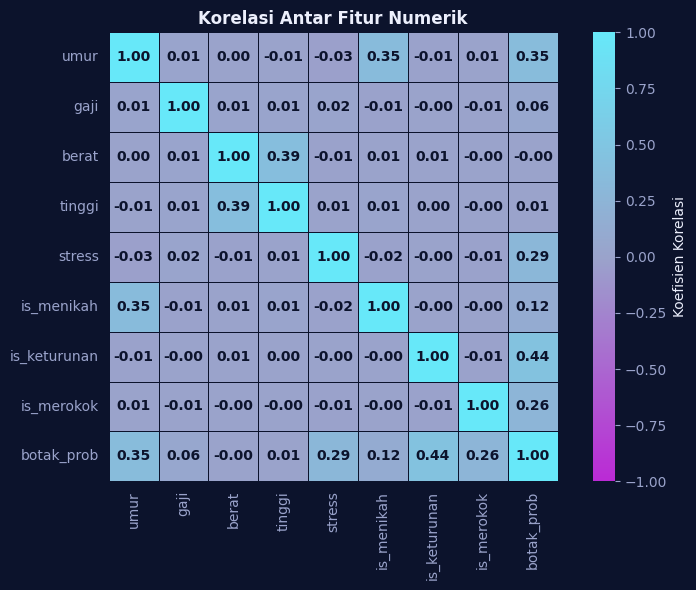

In [10]:
corr_cols = ['umur', 'gaji', 'berat', 'tinggi', 'stress',
             'is_menikah', 'is_keturunan', 'is_merokok', 'botak_prob']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=BRAND_CMAP, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.6, linecolor=BRAND['bg'],
            annot_kws={'color': BRAND['bg'], 'fontweight': 600},
            cbar_kws={'label': 'Koefisien Korelasi'})
plt.title('Korelasi Antar Fitur Numerik', fontweight=700)
plt.tight_layout()
plt.show()

### 4.2 Distribusi Fitur Numerik

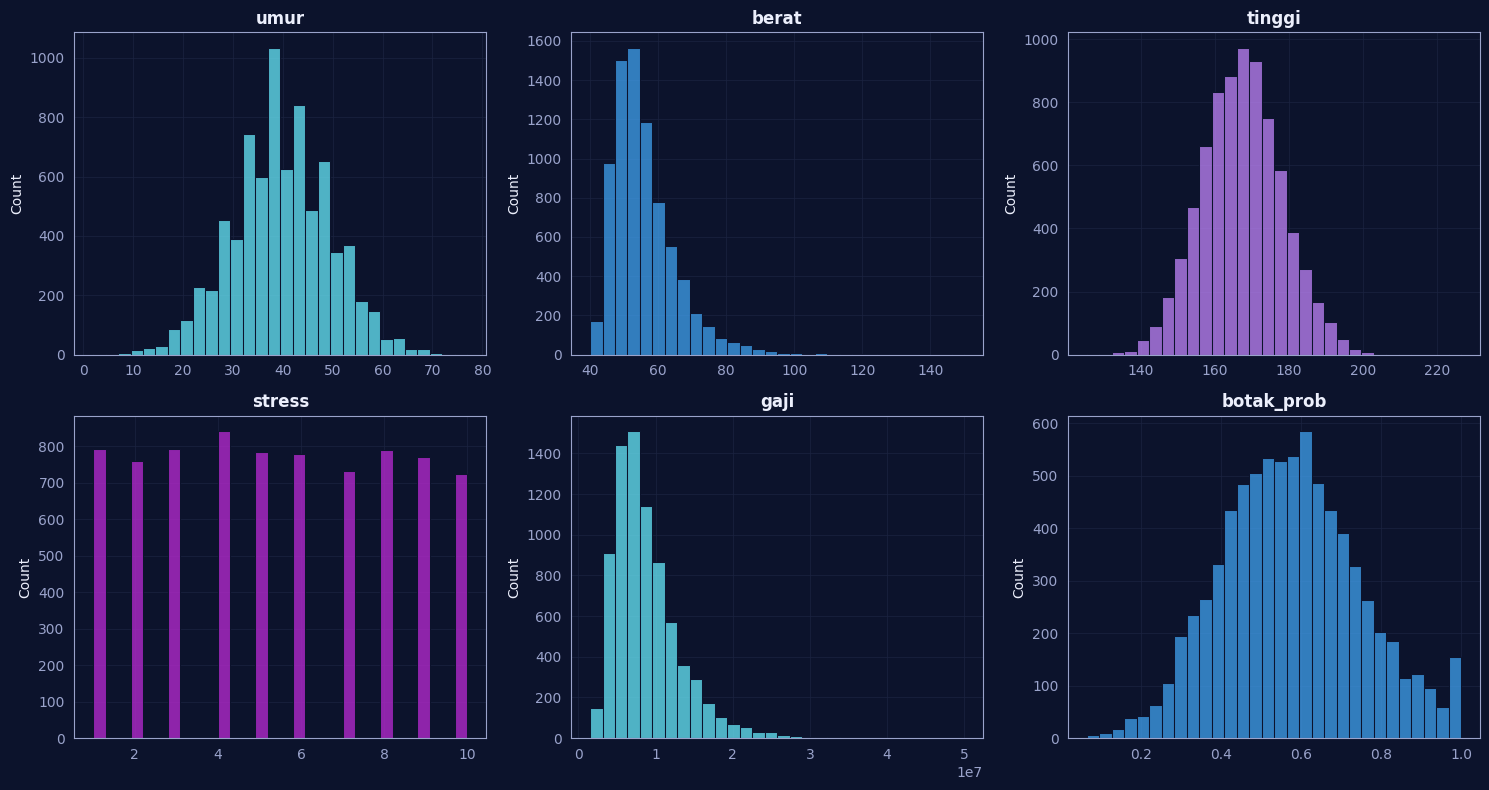

In [11]:
numeric_view = ['umur', 'berat', 'tinggi', 'stress', 'gaji', 'botak_prob']
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()

for ax, col, color in zip(axs, numeric_view, BRAND_PALETTE * 2):
    sns.histplot(df[col], bins=30, color=color, edgecolor=BRAND['bg'], ax=ax)
    ax.set_title(col, fontweight=700)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### 4.3 Komposisi Fitur Kategorikal

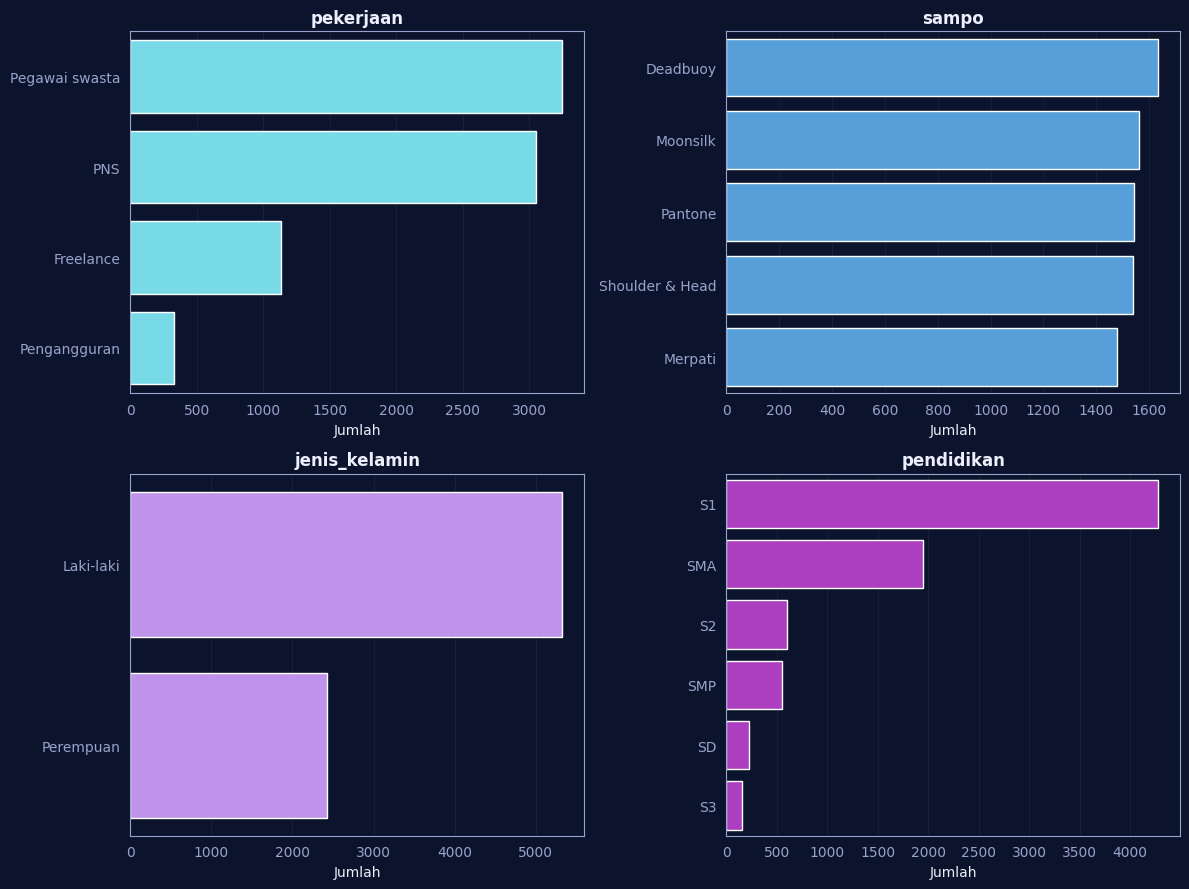

In [12]:
cat_view = ['pekerjaan', 'sampo', 'jenis_kelamin', 'pendidikan']
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs = axs.flatten()

for ax, col, color in zip(axs, cat_view, BRAND_PALETTE):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color=color)
    ax.set_title(col, fontweight=700)
    ax.set_ylabel('')
    ax.set_xlabel('Jumlah')

plt.tight_layout()
plt.show()

### 4.4 Kelompok Risiko Tinggi (`botak_prob` >= 70%)

Jumlah individu risiko tinggi: 1760


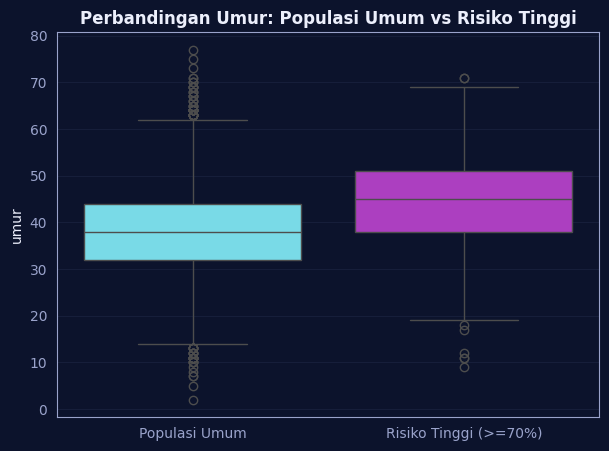

In [13]:
df_risk = df.copy()
df_risk['kelompok'] = np.where(df_risk['botak_prob'] >= 0.7, 'Risiko Tinggi (>=70%)', 'Populasi Umum')

print('Jumlah individu risiko tinggi:', (df_risk['kelompok'] == 'Risiko Tinggi (>=70%)').sum())

kelompok_colors = {'Populasi Umum': BRAND['cyan'], 'Risiko Tinggi (>=70%)': BRAND['magenta']}

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_risk, x='kelompok', y='umur', hue='kelompok',
            palette=kelompok_colors, legend=False)
plt.title('Perbandingan Umur: Populasi Umum vs Risiko Tinggi', fontweight=700)
plt.xlabel('')
plt.show()

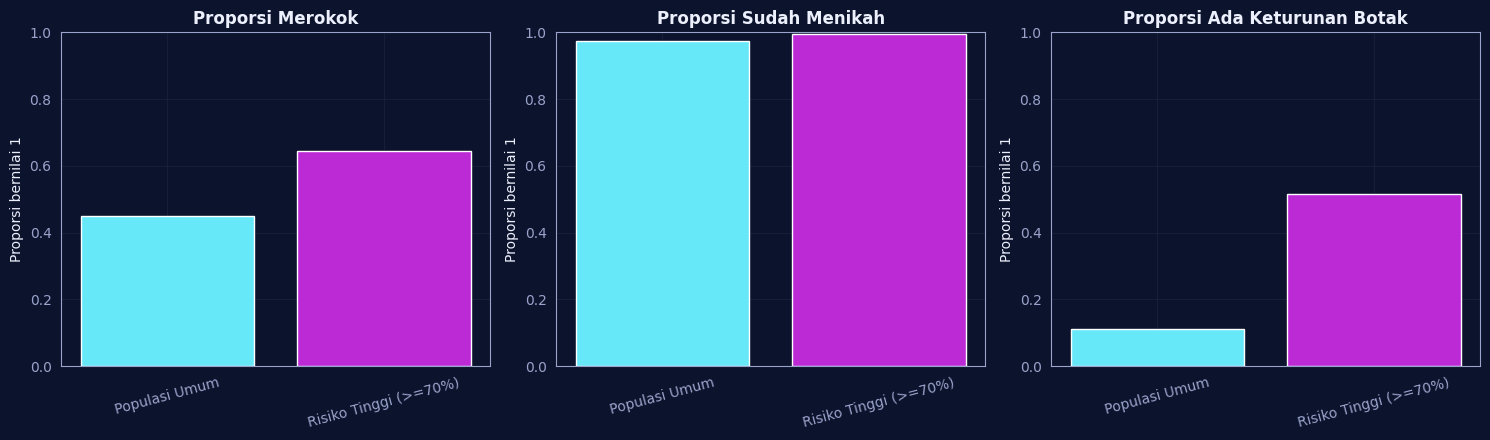

In [14]:
compare_cols = ['is_merokok', 'is_menikah', 'is_keturunan']
titles = {
    'is_merokok': 'Proporsi Merokok',
    'is_menikah': 'Proporsi Sudah Menikah',
    'is_keturunan': 'Proporsi Ada Keturunan Botak',
}

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axs, compare_cols):
    prop = df_risk.groupby('kelompok')[col].mean()
    ax.bar(prop.index, prop.values, color=[kelompok_colors[k] for k in prop.index])
    ax.set_title(titles[col], fontweight=700)
    ax.set_ylabel('Proporsi bernilai 1')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 5) Outlier Handling (IQR) — kolom `tinggi` & `berat`

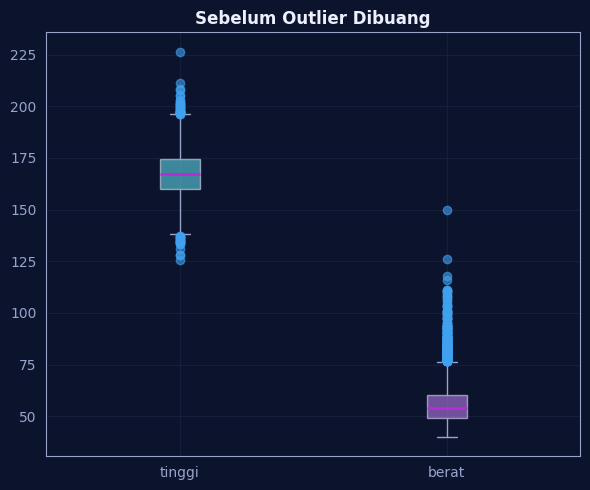

In [15]:
def styled_boxplot(data_cols, labels, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    bp = ax.boxplot(data_cols, tick_labels=labels, patch_artist=True)
    box_colors = [BRAND['cyan'], BRAND['purple']]
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)
        patch.set_edgecolor(BRAND['text'])
    for element in ['whiskers', 'caps']:
        for line in bp[element]:
            line.set_color(BRAND['muted'])
    for median in bp['medians']:
        median.set_color(BRAND['magenta'])
        median.set_linewidth(2)
    for flier in bp['fliers']:
        flier.set_markeredgecolor(BRAND['blue'])
        flier.set_markerfacecolor(BRAND['blue'])
        flier.set_alpha(0.6)
    ax.set_title(title, fontweight=700)
    plt.tight_layout()
    plt.show()

outlier_cols = ['tinggi', 'berat']
styled_boxplot([df[c] for c in outlier_cols], outlier_cols, 'Sebelum Outlier Dibuang')

tinggi: batas IQR = (np.float64(137.9530119988189), np.float64(196.20108309438746))
berat: batas IQR = (np.float64(33.071339556320915), np.float64(76.39896169256016))

Sebelum: 7757 | Sesudah: 7431 | Outlier terhapus: 326


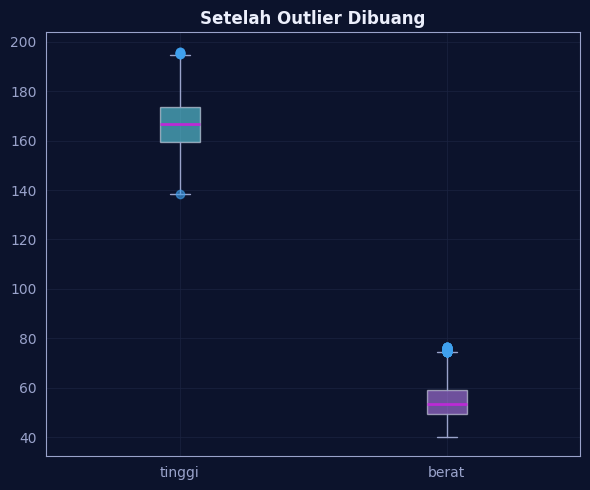

In [16]:
def remove_outliers_iqr(data, col, k=1.5):
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - k*IQR, Q3 + k*IQR
    return data[(data[col] >= lower) & (data[col] <= upper)], (lower, upper)

before = len(df)
for col in outlier_cols:
    df, bounds = remove_outliers_iqr(df, col)
    print(f'{col}: batas IQR = {bounds}')
after = len(df)
print(f'\nSebelum: {before} | Sesudah: {after} | Outlier terhapus: {before - after}')

styled_boxplot([df[c] for c in outlier_cols], outlier_cols, 'Setelah Outlier Dibuang')

## 6) Feature Encoding

Mapping didefinisikan sekali dalam satu dict — dipakai ulang saat training **dan** saat inferensi data baru (menghindari duplikasi kode antara training & prediksi).

In [17]:
encoding_maps = {
    'jenis_kelamin': {'Laki-laki': 1, 'Perempuan': 0},
    'pekerjaan':     {'Freelance': 0, 'PNS': 1, 'Pegawai swasta': 2, 'Pengangguran': 3},
    'sampo':         {'Deadbuoy': 0, 'Merpati': 1, 'Moonsilk': 2, 'Pantone': 3, 'Shoulder & Head': 4},
    'pendidikan':    {'SD': 0, 'SMP': 1, 'SMA': 2, 'S1': 3, 'S2': 4, 'S3': 5},
}

for col, mapping in encoding_maps.items():
    df[col] = df[col].map(mapping)

df[list(encoding_maps.keys())].head()

,jenis_kelamin,pekerjaan,sampo,pendidikan
0,0,1,3,3
1,0,1,3,3
2,0,2,2,3
3,0,3,0,0
4,1,0,1,4


## 7) Split Data

Kolom `gaji` dan `provinsi` **tidak dipakai** sebagai fitur — secara logis tidak relevan untuk memprediksi kebotakan. Scaling fitur dilakukan **di dalam pipeline** masing-masing model (lihat bagian 8), bukan sekali di awal — supaya scaler selalu di-*fit* ulang di tiap fold cross-validation dan benar-benar terisolasi dari data test.

In [18]:
from sklearn.model_selection import train_test_split

feature_cols = ['umur', 'jenis_kelamin', 'pekerjaan', 'is_menikah', 'is_keturunan',
                 'berat', 'tinggi', 'sampo', 'is_merokok', 'pendidikan', 'stress']
target = 'botak_prob'

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (5944, 11) | Test: (1487, 11)


## 8) Modeling & Evaluasi dengan Cross-Validation

Tiap model dibungkus dalam `Pipeline` (`MinMaxScaler` + estimator), lalu dievaluasi dengan **5-fold cross-validation** pada data train — lebih ketat dibanding satu kali split, karena performa diukur di beberapa kombinasi data sekaligus.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

candidate_models = {
    'Regresi Linear': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Support Vector Regression': SVR(),
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_summary = []

for name, estimator in candidate_models.items():
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', estimator),
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='neg_root_mean_squared_error')
    rmse_scores = -scores
    cv_summary.append({'model': name, 'rmse_mean': rmse_scores.mean(), 'rmse_std': rmse_scores.std()})

cv_df = pd.DataFrame(cv_summary).sort_values('rmse_mean').reset_index(drop=True)
cv_df

,model,rmse_mean,rmse_std
0,Random Forest,0.073990,0.005228
1,Support Vector Regression,0.084718,0.003905
2,Decision Tree,0.103056,0.005042
3,Regresi Linear,0.110525,0.003033


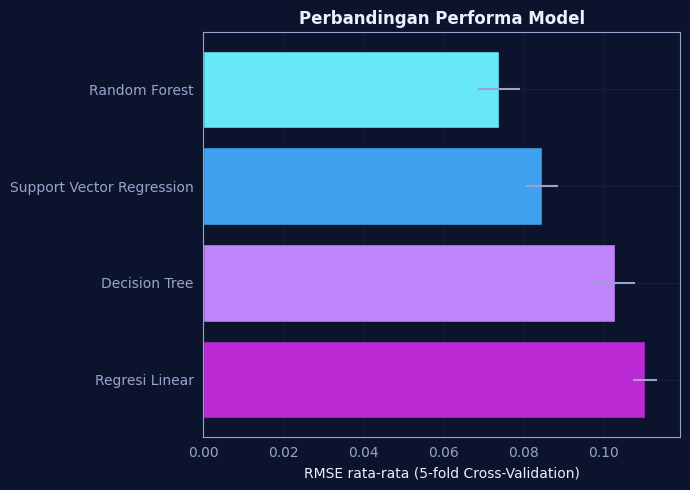

In [20]:
plt.figure(figsize=(7, 5))
bar_colors = BRAND_PALETTE[:len(cv_df)]
plt.barh(cv_df['model'], cv_df['rmse_mean'], xerr=cv_df['rmse_std'],
         color=bar_colors, ecolor=BRAND['muted'], edgecolor=BRAND['bg'])
plt.xlabel('RMSE rata-rata (5-fold Cross-Validation)')
plt.title('Perbandingan Performa Model', fontweight=700)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9) Model Terbaik: Retrain, Evaluasi di Test Set, & Simpan

Model terbaik (CV RMSE terendah): Random Forest
RMSE (test set): 0.06752
R2   (test set): 0.8559


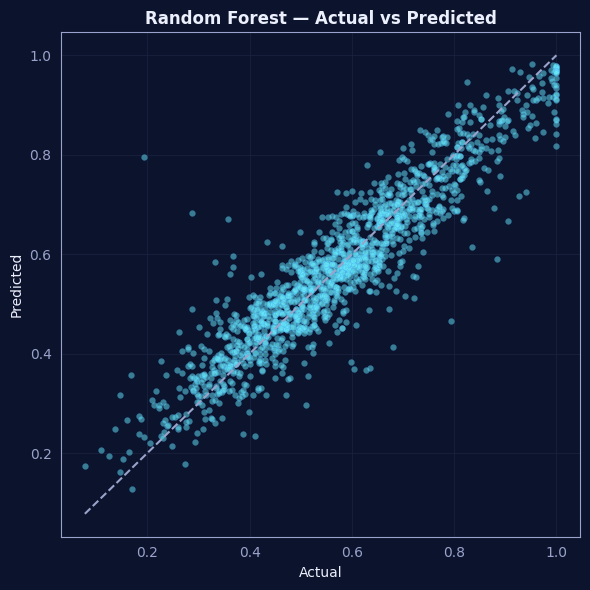

In [21]:
best_name = cv_df.iloc[0]['model']
best_estimator = candidate_models[best_name]

best_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', best_estimator),
])
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print(f'Model terbaik (CV RMSE terendah): {best_name}')
print(f'RMSE (test set): {test_rmse:.5f}')
print(f'R2   (test set): {test_r2:.4f}')

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=18, color=BRAND['cyan'], edgecolor=BRAND['blue'], linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         '--', color=BRAND['muted'], lw=1.5)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'{best_name} — Actual vs Predicted', fontweight=700)
plt.tight_layout()
plt.show()

Simpan pipeline lengkap (scaler + model), mapping encoding, dan dataset bersih dalam satu bundle.

In [22]:
artifact = {
    'pipeline': best_pipeline,
    'model_name': best_name,
    'encoding_maps': encoding_maps,
    'feature_cols': feature_cols,
}

with open('botak_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print('Tersimpan: botak_model.pkl')

Tersimpan: botak_model.pkl


In [23]:
df.to_csv('botak_bersih.csv', index=False)
print('Tersimpan: botak_bersih.csv')

Tersimpan: botak_bersih.csv


## 10) Pipeline Inferensi ke Data Baru

Karena scaler sudah menyatu di dalam `pipeline`, fungsi `preprocess_new_data` cukup melakukan encoding kategori & seleksi kolom — proses scaling otomatis dijalankan saat `pipeline.predict()` dipanggil.

In [24]:
def preprocess_new_data(data_baru: pd.DataFrame, artifact: dict) -> pd.DataFrame:
    data = data_baru.copy()
    for col, mapping in artifact['encoding_maps'].items():
        data[col] = data[col].map(mapping)
    return data[artifact['feature_cols']]

with open('botak_model.pkl', 'rb') as f:
    artifact = pickle.load(f)

new_df = pd.DataFrame({
    'umur': [40],
    'jenis_kelamin': ['Laki-laki'],
    'pekerjaan': ['Pegawai swasta'],
    'is_menikah': [1],
    'is_keturunan': [1],
    'berat': [65],
    'tinggi': [170],
    'sampo': ['Pantone'],
    'is_merokok': [1],
    'pendidikan': ['S2'],
    'stress': [7],
})

X_new = preprocess_new_data(new_df, artifact)
prediksi = float(artifact['pipeline'].predict(X_new)[0])

print(f"Model dipakai   : {artifact['model_name']}")
print('Data baru:')
display(new_df)
print(f'\nKemungkinan Botak: {prediksi:.1%}')

Model dipakai   : Random Forest
Data baru:


,umur,jenis_kelamin,pekerjaan,is_menikah,is_keturunan,berat,tinggi,sampo,is_merokok,pendidikan,stress
0,40,Laki-laki,Pegawai swasta,1,1,65,170,Pantone,1,S2,7



Kemungkinan Botak: 64.1%


---
**Selesai.** Notebook ini menghasilkan 2 file: `botak_bersih.csv` (dataset bersih) dan `botak_model.pkl` (bundle model + scaler + mapping encoding, siap dipakai ulang tanpa training ulang).